[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/07_data_vis/07_1_Why_Visualize.ipynb)

# 07.1: Why Visualize?

In module 6, you learned to ask questions of a dataset and get numbers back: what is the average age, how many passengers were in each class, what proportion survived. Those are useful answers. But they leave a lot out.

This notebook makes the case for visualization: what charts reveal that numbers cannot. It also introduces the three Python libraries that power every chart in this module and shows you the pattern that almost every seaborn chart follows.

By the end you will have made your first charts and set up the visual environment that all later notebooks in this module share.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]].copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


## What numbers tell you (and what they don't)

We have 891 passengers, though not all have recorded ages. Let's start with the kind of summary you already know how to produce.

> The dataset here comes from seaborn's built-in library (`sns.load_dataset("titanic")`). It has 891 rows, four more than the cleaned CSV used in module 06. The column names are the same, so all the pandas skills carry over directly.

In [2]:
df[["age", "fare"]].describe()

,age,fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


The table tells you the mean age is around 30 and the standard deviation is about 14. The mean fare is around 32 with a standard deviation of nearly 50.

Now ask yourself: what don't you know from that table?

You don't know whether age is evenly spread from 0 to 80 or clustered in one part. You don't know if the large fare standard deviation comes from a handful of very expensive tickets or from a general spread. You don't know the **shape** of either distribution.

Shape turns out to matter quite a bit. Two datasets can have identical means and standard deviations but look completely different. The only way to see shape is to look at it.

Here is one function call that shows you more about `age` than the entire table above.

Text(0.5, 0, 'Age (years)')

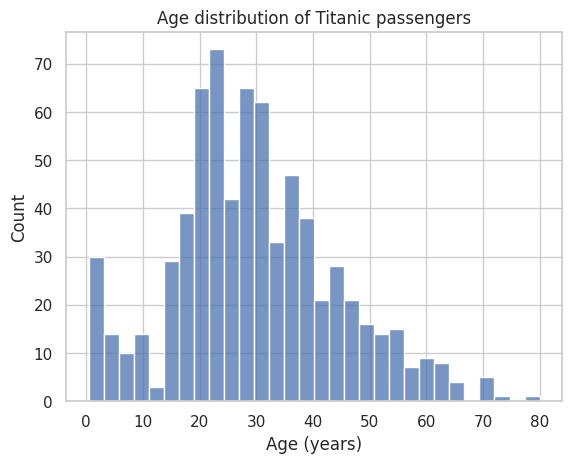

In [3]:
ax = sns.histplot(data=df, x="age", bins=30)
ax.set_title("Age distribution of Titanic passengers")
ax.set_xlabel("Age (years)")

The histogram shows you something the table could not: the age distribution peaks in the 20s and 30s and tapers off in both directions. The shape is roughly symmetric, which is why the mean (30) and the median (28, the `50%` row) are close together. The standard deviation of 14 now has a visual meaning: most passengers fall within one standard deviation of the mean, between roughly 16 and 44.

Now look at fare.

Text(0.5, 0, 'Fare (British pounds)')

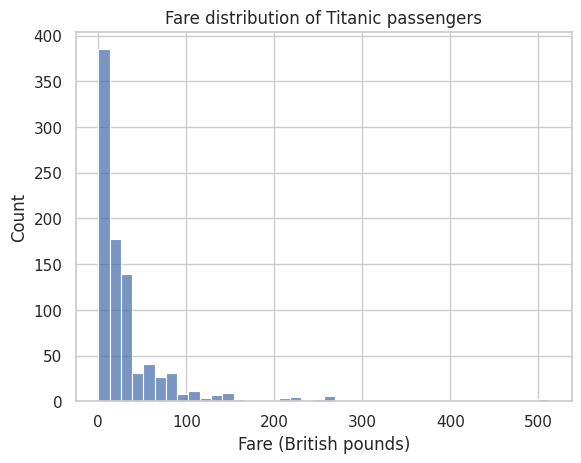

In [4]:
ax = sns.histplot(data=df, x="fare", bins=40)
ax.set_title("Fare distribution of Titanic passengers")
ax.set_xlabel("Fare (British pounds)")

The fare distribution tells a completely different story. The overwhelming majority of passengers paid under 50 pounds, but a long tail of expensive tickets stretches far to the right. A distribution with this shape is called **right-skewed**: most values are low, but a small number of extreme high values pull the mean upward.

When you saw that the mean fare was 32 and the standard deviation was nearly 50 in the table, that unusually large standard deviation was a hint that something was going on. But the histogram makes it immediate: a handful of very expensive tickets are distorting the average. The "typical" fare is actually closer to the tallest bar on the left than to the mean of 32.

This is the core argument for visualization. Numbers summarize. Charts reveal.

## Three libraries, one chart

When you called `sns.histplot(data=df, x="age")`, three different pieces of software worked together to produce that chart. Understanding which one did what will save you confusion later.

**pandas** owns the data. A DataFrame is the raw material: a table of rows and columns that you already know how to query, filter, and aggregate. Every chart in this module starts with a pandas DataFrame.

**matplotlib** owns the canvas. It is a low-level plotting library that has been part of the Python ecosystem since 2003. Every chart you will see in this module is ultimately drawn by matplotlib: every bar, every dot, every axis label. The catch is that using matplotlib directly requires you to pass raw arrays of numbers and specify the geometry of your chart in considerable detail. For statistical charts, that is tedious.

**seaborn** provides a higher-level interface on top of matplotlib, designed specifically for statistical charts. Instead of passing arrays, you pass a DataFrame and the names of the columns you want to visualize. Seaborn handles the statistics (computing bin heights, fitting curves, calculating confidence intervals) and hands the drawing off to matplotlib.

A useful mental model: pandas prepares the ingredients, seaborn writes the recipe, and matplotlib does the cooking. In practice you will use all three: seaborn to draw the chart, matplotlib to fine-tune labels and sizes, and pandas to prepare the data.

## The seaborn call signature

Almost every seaborn chart follows the same basic pattern:

```python
sns.some_chart(data=df, x="column_name")
```

The `data=` argument takes your DataFrame. The `x=` argument takes the name of a column as a string. Many charts also accept `y=`, `hue=`, and other arguments, all of which also take column names as strings.

Compare that to drawing the same histogram in raw matplotlib:

```python
plt.hist(df["age"].dropna(), bins=30)
```

Both produce a histogram. But the seaborn version has an important advantage: because seaborn holds a reference to the whole DataFrame, adding more variables to the chart requires nothing more than an extra keyword argument. If you want to color the bars by survival status, you simply add `hue="survived"`. In matplotlib, you would split the DataFrame yourself, loop over the groups, and call `plt.hist()` separately for each one.

The gap between the two approaches widens every time you add a variable. You will see this in notebook 07.2, where we start layering variables onto our charts.

## Two families of seaborn functions

Seaborn has two families of chart functions, and knowing which family a function belongs to will explain behavior that would otherwise seem arbitrary.

**Axes-level functions** draw a single chart into one panel. They return a matplotlib **Axes** object, which you can use to add a title, change axis labels, or adjust limits. `sns.histplot()` is an axes-level function; so are `sns.scatterplot()`, `sns.boxplot()`, and most of the specific chart functions you will encounter in this module.

**Figure-level functions** create a complete figure, potentially containing multiple panels arranged in a grid. They return a **FacetGrid** object rather than an Axes. `sns.displot()` is the figure-level counterpart to `sns.histplot()`. Figure-level functions become important in notebook 07.5, when we want to split a chart into a grid of small panels, one per category.

> A note on terminology: in matplotlib, a **Figure** is the whole image (think of it as the blank sheet of paper). An **Axes** is one chart within that figure (the panel where data is actually drawn). A figure can contain many Axes. When seaborn says "axes-level," it means the function draws into one panel and returns that panel. When it says "figure-level," it means the function manages the whole page.

The code below creates the same histogram using each family and shows what each returns.

Return type: <class 'matplotlib.axes._axes.Axes'>


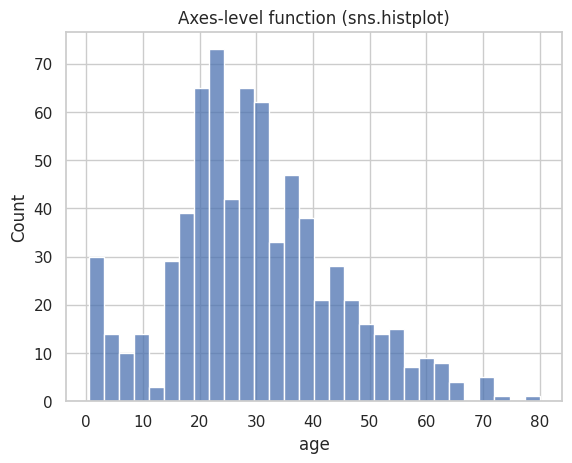

In [5]:
# Axes-level: draws one panel, returns a matplotlib Axes
ax = sns.histplot(data=df, x="age", bins=30)
ax.set_title("Axes-level function (sns.histplot)")
print("Return type:", type(ax))

Return type: <class 'seaborn.axisgrid.FacetGrid'>


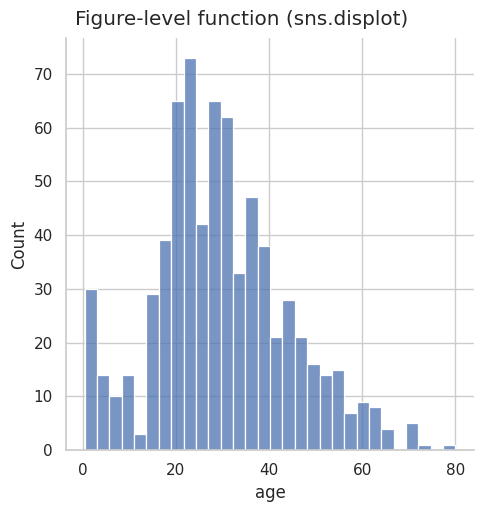

In [6]:
# Figure-level: builds a whole figure, returns a FacetGrid
g = sns.displot(data=df, x="age", bins=30)
g.figure.suptitle("Figure-level function (sns.displot)", y=1.02)
print("Return type:", type(g))

The charts look nearly identical, but the return type is different. That difference matters when you want to add titles, adjust labels, or resize. Axes-level functions respond to `ax.set_title(...)`. Figure-level functions respond to `g.figure.suptitle(...)` and `g.set_axis_labels(...)`. We will cover all of this in detail in notebook 07.7, once you have a full toolkit of charts to polish.

For now, the practical takeaway is: most of the charts in notebooks 07.2 through 07.6 are axes-level. When a function returns a `FacetGrid` instead of an `Axes`, you will know to use `g.` methods rather than `ax.` methods.

## Setting the visual style once

Near the top of every notebook in this module you will see this line:

```python
sns.set_theme(style="whitegrid", context="notebook")
```

Calling `sns.set_theme()` once sets the default appearance for every chart that follows in the session. The `style=` argument controls the background and grid lines. The `context=` argument controls font sizes: `"notebook"` is calibrated for Jupyter; `"talk"` makes everything larger for presentations.

Seaborn ships with five built-in styles. Here is the same histogram drawn with three of them so you can see the difference.

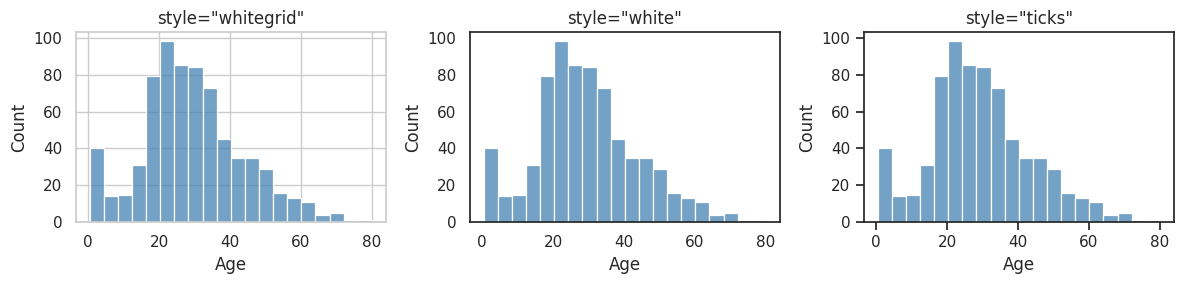

In [7]:
fig = plt.figure(figsize=(12, 3))
styles = ["whitegrid", "white", "ticks"]

for i, style in enumerate(styles, 1):
    with sns.axes_style(style):
        ax = fig.add_subplot(1, 3, i)
        sns.histplot(data=df, x="age", bins=20, ax=ax, color="steelblue")
    ax.set_title(f'style="{style}"')
    ax.set_xlabel("Age")

plt.tight_layout()

This module uses `"whitegrid"` throughout. The grid lines make it easier to read approximate values from a chart while you are building your eye for data. Once you have more experience you may prefer the cleaner look of `"white"` or `"ticks"` for polished outputs.

The two remaining styles, `"darkgrid"` and `"dark"`, use a gray background. Some people find them easier to read on screens; others find them harder to print. Try them and decide for yourself.

## What's next

You have made four histograms, seen where seaborn fits in the Python stack, and set up the visual environment for the rest of this module. In notebook 07.2 we go deep on one chart family: distributions. You will learn to describe not just the mean and standard deviation of a variable but its full shape, and then compare shapes across groups. The single `histplot` call you saw here turns out to have a lot more to say.